# Week 3 – The Cleaning Sprint

## Objective

The objective of Week 3 is to clean and prepare the dataset for further analysis.

The following data cleaning tasks will be performed:

1. Handle missing values appropriately
2. Check and correct incorrect data types
3. Check inconsistent text values
4. Detect outliers
5. Handle outliers
6. Remove duplicate records
7. Perform final cleaning verification
8. Save the cleaned dataset



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving data_jobs.csv to data_jobs.csv


## Loading the Dataset

The original dataset is loaded into a Pandas DataFrame. The dataset will be examined before applying any cleaning techniques.

In [5]:
import pandas as pd

df = pd.read_csv("data_jobs.csv")

In [6]:
print("Shape:", df.shape)

Shape: (785741, 17)


In [7]:
print("Missing salary_year_avg:", df["salary_year_avg"].isna().sum())
print("Missing salary_hour_avg:", df["salary_hour_avg"].isna().sum())

Missing salary_year_avg: 763738
Missing salary_hour_avg: 775079


## Missing Value Analysis

Missing values are identified in each column to understand the extent of incomplete information in the dataset.

The number and percentage of missing values are calculated before applying any cleaning strategy.

In [8]:
missing_count = df.isnull().sum()
missing_count

,0
job_title_short,0
job_title,1
job_location,1045
job_via,8
job_schedule_type,12667
job_work_from_home,0
search_location,0
job_posted_date,0
job_no_degree_mention,0
job_health_insurance,0


In [9]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percentage

,0
salary_hour_avg,98.643064
salary_year_avg,97.199713
salary_rate,95.791616
job_type_skills,14.895112
job_skills,14.895112
job_schedule_type,1.612109
job_location,0.132995
job_country,0.006236
company_name,0.002291
job_via,0.001018


In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
job_title,1
job_location,1045
job_via,8
job_schedule_type,12667
job_country,49
salary_rate,752674
salary_year_avg,763738
salary_hour_avg,775079
company_name,18
job_skills,117037


### Observation

The missing-value analysis shows that salary-related attributes contain the highest number of missing values. The `salary_year_avg` and `salary_hour_avg` columns have many missing values because salary information is not available for most job postings. The `job_skills` and `job_type_skills` columns also contain missing values. Categorical attributes such as `job_title`, `job_location`, `job_via`, `job_schedule_type`, `job_country`, and `company_name` contain comparatively fewer missing values.

## Handling Missing Values

Missing values are handled according to the meaning of each attribute. Categorical attributes with a small number of missing values are replaced with `"Not Specified"`. Salary and skill-related attributes are retained as missing because their absence represents unavailable information rather than a value that should be artificially estimated.

In [11]:
categorical_columns = [
    "job_title",
    "job_location",
    "job_via",
    "job_schedule_type",
    "job_country",
    "company_name"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Not Specified")

print("Categorical missing values handled successfully!")

Categorical missing values handled successfully!


In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
salary_rate,752674
salary_year_avg,763738
salary_hour_avg,775079
job_skills,117037
job_type_skills,117037


### Missing Value Verification

The categorical attributes with a small number of missing values have been successfully handled using `"Not Specified"`.

Salary-related and skill-related attributes still contain missing values. These missing values are retained because they represent information that was not provided in the original job postings. Imputing these fields could introduce misleading information into the dataset.

## Data Type Verification

The data types of all attributes are checked to identify values stored in an inappropriate format.

No unnecessary conversion is performed. Any required corrections are applied only when the data type is inconsistent with the meaning of the attribute.

In [13]:
df.dtypes

,0
job_title_short,object
job_title,object
job_location,object
job_via,object
job_schedule_type,object
job_work_from_home,bool
search_location,object
job_posted_date,object
job_no_degree_mention,bool
job_health_insurance,bool


In [14]:
df["job_posted_date"].head()

,job_posted_date
0,2023-06-16 13:44:15
1,2023-01-14 13:18:07
2,2023-10-10 13:14:55
3,2023-07-04 13:01:41
4,2023-08-07 14:29:36


In [16]:
df["job_posted_date"] = pd.to_datetime(
    df["job_posted_date"],
    errors="coerce"
)

In [17]:
df["job_posted_date"].dtype

dtype('<M8[ns]')

### Observation

The data type verification showed that most attributes had appropriate data types. The `job_posted_date` column was initially stored as an object and was converted to `datetime64[ns]` because it contains date and time information. The remaining attributes have suitable data types for further analysis.

## Checking Inconsistent Text Values

Categorical attributes are checked for inconsistent text representations such as different capitalization, spelling, or formatting.

The unique value counts are inspected to identify possible inconsistencies.

In [18]:
df["job_schedule_type"].value_counts(dropna=False).head(20)

,count
job_schedule_type,
Full-time,701727
Contractor,34793
Not Specified,12667
Internship,8742
Part-time,7881
Full-time and Part-time,6287
Full-time and Temp work,2603
Full-time and Internship,2340
Full-time and Contractor,2292


In [19]:
df["job_title_short"].value_counts(dropna=False).head(20)

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


In [20]:
df["job_country"].value_counts(dropna=False).head(20)

,count
job_country,
United States,206292
India,51088
United Kingdom,40375
France,39922
Germany,27694
Spain,25100
Singapore,23696
Sudan,21781
Netherlands,20631


In [21]:
df["job_via"].value_counts(dropna=False).head(20)

,count
job_via,
via LinkedIn,186679
via BeBee,103507
via Trabajo.org,61562
via Indeed,42756
via Recruit.net,23646
via ZipRecruiter,15533
via Jobs Trabajo.org,10605
via Snagajob,9355
"via Trabajo.org - Vacantes De Empleo, Trabajo",8919


In [22]:
df["salary_rate"].value_counts(dropna=False)

,count
salary_rate,
NaN,752674
year,22004
hour,10662
month,382
week,10
day,9


In [23]:
df["company_name"].value_counts(dropna=False).head(20)

,count
company_name,
Emprego,6664
Booz Allen Hamilton,2879
Dice,2827
Harnham,2547
Insight Global,2254
Citi,2164
Confidenziale,2040
Listopro,1984
Capital One,1946


### Observation

The categorical attributes were examined for inconsistent text representations such as differences in capitalization, spelling, and formatting.

The inspected values showed consistent formatting and no obvious duplicate representations caused by text inconsistencies. Different job schedule combinations, job sources, salary periods, countries, and company names were retained because they represent distinct valid categories.

Therefore, no further text standardization was required.

## Outlier Detection

Outliers are identified in numerical salary attributes using the Interquartile Range (IQR) method.

Only non-missing salary values are considered for outlier detection because missing values represent unavailable salary information.

In [24]:
salary_year = df["salary_year_avg"].dropna()

Q1 = salary_year.quantile(0.25)
Q3 = salary_year.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_year = salary_year[
    (salary_year < lower_bound) | (salary_year > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers_year))

Q1: 90000.0
Q3: 150000.0
IQR: 60000.0
Lower Bound: 0.0
Upper Bound: 240000.0
Number of Outliers: 416


### Observation

The IQR method identified 416 potential outliers in the `salary_year_avg` attribute. The lower bound was 0 and the upper bound was 240,000. These values were flagged for further inspection rather than immediately removed because some high salary values may represent genuine job postings.

In [25]:
salary_hour = df["salary_hour_avg"].dropna()

Q1 = salary_hour.quantile(0.25)
Q3 = salary_hour.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_hour = salary_hour[
    (salary_hour < lower_bound) | (salary_hour > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers_hour))

Q1: 27.5
Q3: 61.15999603271485
IQR: 33.65999603271485
Lower Bound: -22.98999404907228
Upper Bound: 111.64999008178714
Number of Outliers: 77


### Observation

The IQR method identified 77 potential outliers in the `salary_hour_avg` attribute. The lower bound was -22.99 and the upper bound was 111.65. Since hourly salary cannot normally be negative, the main focus is on values above the upper bound. The identified values are treated as potential outliers and are inspected before deciding whether they should be removed.

### Boxplot for Salary Attributes

Boxplots are used to visually identify extreme salary values. Points beyond the whiskers indicate potential outliers.

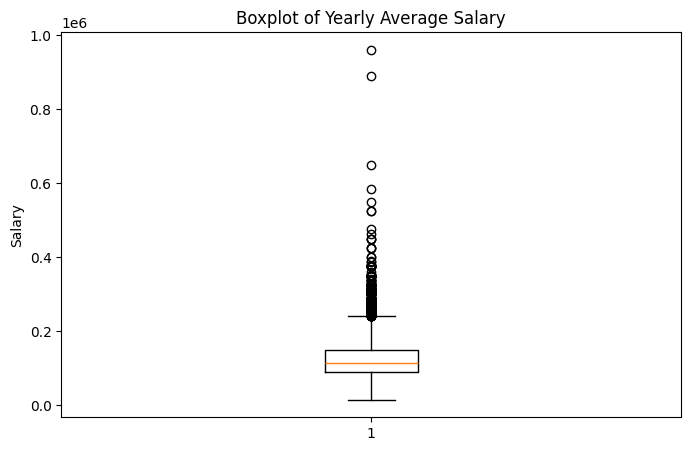

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df["salary_year_avg"].dropna())
plt.title("Boxplot of Yearly Average Salary")
plt.ylabel("Salary")
plt.show()

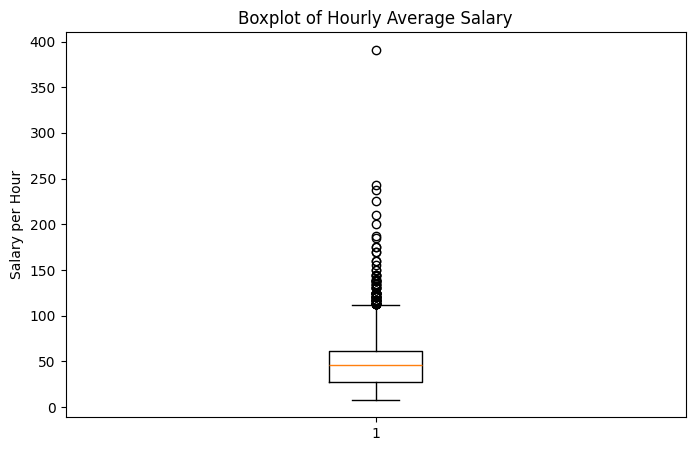

In [27]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["salary_hour_avg"].dropna())
plt.title("Boxplot of Hourly Average Salary")
plt.ylabel("Salary per Hour")
plt.show()

## Handling Outliers

Potential outliers were identified in the salary attributes using the IQR method.

Instead of removing the records, outlier values are capped at the calculated IQR boundaries. This approach preserves the original job postings while reducing the influence of extreme salary values on statistical analysis.

In [28]:
Q1_year = df["salary_year_avg"].quantile(0.25)
Q3_year = df["salary_year_avg"].quantile(0.75)

IQR_year = Q3_year - Q1_year

lower_year = Q1_year - 1.5 * IQR_year
upper_year = Q3_year + 1.5 * IQR_year

df["salary_year_avg"] = df["salary_year_avg"].clip(
    lower=lower_year,
    upper=upper_year
)

print("Yearly salary outliers handled successfully!")

Yearly salary outliers handled successfully!


In [29]:
Q1_hour = df["salary_hour_avg"].quantile(0.25)
Q3_hour = df["salary_hour_avg"].quantile(0.75)

IQR_hour = Q3_hour - Q1_hour

lower_hour = Q1_hour - 1.5 * IQR_hour
upper_hour = Q3_hour + 1.5 * IQR_hour

df["salary_hour_avg"] = df["salary_hour_avg"].clip(
    lower=lower_hour,
    upper=upper_hour
)

print("Hourly salary outliers handled successfully!")

Hourly salary outliers handled successfully!


In [30]:
print("Yearly salary minimum:", df["salary_year_avg"].min())
print("Yearly salary maximum:", df["salary_year_avg"].max())

print("Hourly salary minimum:", df["salary_hour_avg"].min())
print("Hourly salary maximum:", df["salary_hour_avg"].max())

Yearly salary minimum: 15000.0
Yearly salary maximum: 240000.0
Hourly salary minimum: 8.0
Hourly salary maximum: 111.64999008178714


### Observation

The detected salary outliers were handled using IQR-based capping. Extreme values were limited to the calculated lower and upper bounds instead of removing complete job-posting records. This preserves the dataset size while reducing the effect of extreme salary values during further analysis.

## Final Cleaning Verification

The cleaned dataset is verified to ensure that the required cleaning operations were successfully completed. Missing values, data types, duplicate records, and dataset dimensions are checked before saving the cleaned dataset.

In [31]:
missing_final = df.isnull().sum()
missing_final[missing_final > 0]


,0
salary_rate,752674
salary_year_avg,763738
salary_hour_avg,775079
job_skills,117037
job_type_skills,117037


In [32]:
df.dtypes

,0
job_title_short,object
job_title,object
job_location,object
job_via,object
job_schedule_type,object
job_work_from_home,bool
search_location,object
job_posted_date,datetime64[ns]
job_no_degree_mention,bool
job_health_insurance,bool


In [33]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 101


In [34]:
print("Final dataset shape:", df.shape)

Final dataset shape: (785741, 17)


### Duplicate Removal

Duplicate records are removed to ensure that the same job posting is not counted more than once. The number of duplicate rows is checked before and after removal.

In [35]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 101
Duplicates after: 0


In [36]:
print("Final dataset shape:", df.shape)

Final dataset shape: (785640, 17)


### Final Cleaning Verification – Observation

The final verification confirmed that the categorical missing values were handled appropriately, while salary and skill-related missing values were retained because they represent unavailable information. The `job_posted_date` attribute was converted to datetime format, salary outliers were capped using IQR-based bounds, and duplicate records were removed. The cleaned dataset is now ready to be saved for further analysis.

In [37]:
df.to_csv("data_jobs_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)

Cleaned dataset saved successfully!
Final shape: (785640, 17)


In [38]:
from google.colab import files

files.download("data_jobs_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>